In [2]:
from scripts import plugin_loader  # noqa: F401
from scripts.abstract_pyprocessor import PyProcessor
import cv2
import matplotlib.pyplot as plt

print(f"Registered processors: {PyProcessor.get_registry()}")

Registered processors: {'mfccd': <class 'scripts.matched_filter_pyprocessor.MatchedFilterPyProcessor'>, 'smf': <class 'scripts.matched_filter_pyprocessor.SmallMFPyProcessor'>, 'mfgamma': <class 'scripts.matched_filter_pyprocessor.MFGammaPyProcessor'>, 'mfsigmoid': <class 'scripts.matched_filter_pyprocessor.MFSigmoidPyProcessor'>, 'mfhyst': <class 'scripts.matched_filter_pyprocessor.MFHysteresisPyProcessor'>, 'mfhgamma': <class 'scripts.matched_filter_pyprocessor.MFHystGammaPyProcessor'>, 'mfhsigmoid': <class 'scripts.matched_filter_pyprocessor.MFHystSigmoidPyProcessor'>, 'fmm': <class 'scripts.fmmorph_pyprocessor.FMMorphPyProcessor'>, 'cont': <class 'scripts.contour_pyprocessor.ContourPyProcessor'>}


## Testing Environment
Defines environment variables required for testing.
- `images_directory`: directory to search for test images
- `annotations_directory`: directory to search for related annotation segmentation masks (denotes ground truth)
- `images`: dictionary holding test image to ground truth mappings
- `methods`: set of methods to test with the dispatcher in `PyProcessor`

In [3]:
images_directory = '../images/'
annotations_directory = '../images/annotated/'

images = {
    "0078.tif": "0078.png",
    "0079.tif": "0079.png",
    "0080.tif": "0080.png",
    "0081.tif": "0081.png",
    "0082.tif": "0082.png",
    "0083.tif": "0083.png",
    "0098.tif": "0098.png",
    "0099.tif": "0099.png",
    "0101.tif": "0101.png",
    "0102.tif": "0102.png",
    "0104.tif": "0104.png",
    "0105.tif": "0105.png",
    "0145.tif": "0145.png",
    "0146.tif": "0146.png",
    "0147.tif": "0147.png",
    "0148.tif": "0148.png",
    "0152.tif": "0152.png",
    "0154.tif": "0154.png",
    "0156.jpg": "0156.png",
    "0157.jpg": "0157.png",
    "0158.jpg": "0158.png",
    "0159.jpg": "0159.png",
    "0160.jpg": "0160.png",
    "0161.jpg": "0161.png",
    "0162.jpg": "0162.png",
    "0163.jpg": "0163.png",
    "0164.jpg": "0164.png",
    "0165.jpg": "0165.png",
    "0166.jpg": "0166.png",
    "0167.jpg": "0167.png",
    "0168.jpg": "0168.png",
    "0169.jpg": "0169.png",
}

methods = {
    "mfccd",
    "mfgamma",
    "mfsigmoid",
    "mfhyst",
    "mfhgamma",
    "mfhsigmoid",
    "fmm",
    "smf"
}

## Scoring Logic
Iterates over the image-annotation pairs within the `images` dictionary and processes each image according to each method denoted in the `methods` set. The results are scored based on the annotation (ground truth):
- Intersection over Union: approximation of worst-case performance
- Dice: approximation of average-case performance
- Percent error: total number of false positives and false negatives

In [4]:
from joblib import Memory
import pandas as pd
import seaborn as sns
import score

cache_directory = "./__segcache__"
memory = Memory(cache_directory, verbose=0)


@memory.cache
def benchmark(image_path: str, annotation_path: str, method: str) -> dict:
    image = cv2.imread(images_directory + image_path, cv2.IMREAD_GRAYSCALE)
    assert image is not None

    ground_truth = cv2.imread(
        annotations_directory + annotation_path, cv2.IMREAD_GRAYSCALE
    )
    assert ground_truth is not None

    PyProcessor.dispatch_execute(method, image)

    cv2.imwrite(
        f"{processed_directory}{method}_{image_path[: image_path.find('.')]}.png",
        image,
    )

    return {
        "image_path": image_path,
        "method_name": method,
        "iou": score.iou(image, ground_truth),
        "dice": score.dice(image, ground_truth),
        "percent_err": score.percent_err(image, ground_truth),
    }


processed_directory = "../processed/"

results = []

for image_path, annotation_path in images.items():
    ground_truth = cv2.imread(
        annotations_directory + annotation_path, cv2.IMREAD_GRAYSCALE
    )
    assert ground_truth is not None

    for method in methods:
        # UNCOMMENT TO RERUN
        # benchmark.call(
        #     image_path=image_path, annotation_path=annotation_path, method=method
        # )

        results.append(benchmark(image_path, annotation_path, method))


In [5]:
df = pd.DataFrame(results)
df


,image_path,method_name,iou,dice,percent_err
0,0078.tif,mfsigmoid,0.420158,0.591706,0.036111
1,0078.tif,fmm,0.539614,0.700973,0.032015
2,0078.tif,mfccd,0.420158,0.591706,0.036111
3,0078.tif,mfgamma,0.420158,0.591706,0.036111
4,0078.tif,smf,0.000000,0.000000,0.058105
...,...,...,...,...,...
251,0169.jpg,mfgamma,0.044248,0.084745,0.106032
252,0169.jpg,smf,0.000000,0.000000,0.005808
253,0169.jpg,mfhyst,0.028826,0.056036,0.177084
254,0169.jpg,mfhsigmoid,0.044248,0.084745,0.106032


## Metric Distributions
With the number of images we've tested, results grouped by metric alone varied widely. IoU and Dice appear evenly distributed along the range [0.0, 0.9). Later on in this notebook, we threshold our results to see when methods start to increase in performance.

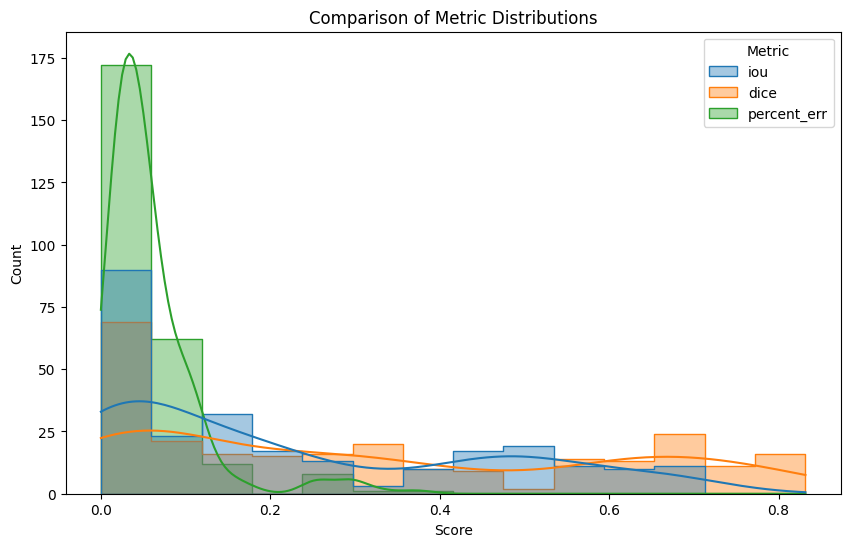

In [6]:
plt.figure(figsize=(10, 6))

# "melt" dataframe to make it compatible with Seaborn's multi-plot logic
df_melted = df.melt(
    value_vars=["iou", "dice", "percent_err"], var_name="Metric", value_name="Score"
)

# create the histogram with a KDE curve
sns.histplot(
    data=df_melted, x="Score", hue="Metric", kde=True, element="step", alpha=0.4
)

plt.title("Comparison of Metric Distributions")
plt.show()

## Method Distributions
Notice that the method type hardly played a factor in Dice score. Keep this in mind for later on.

Text(0.5, 0.98, 'Metric Performance by Method')

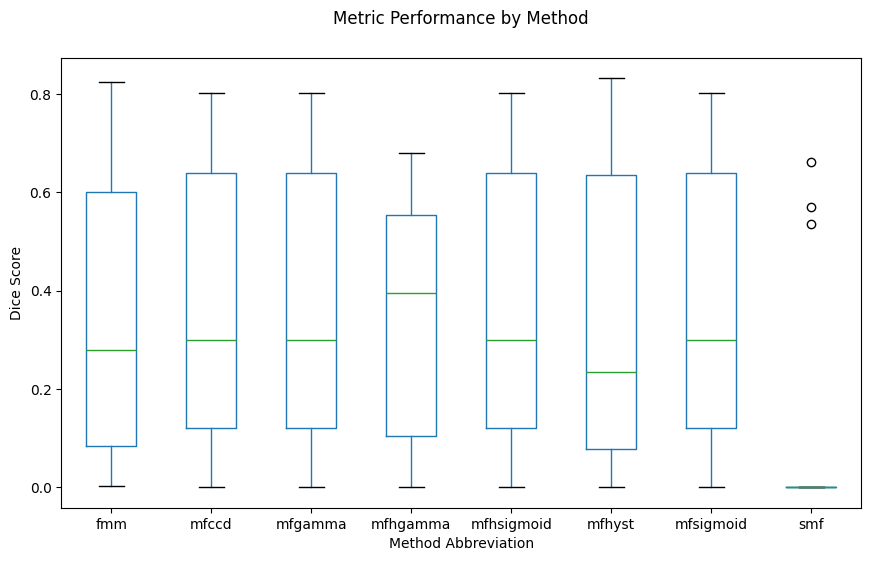

In [7]:
ax = df.boxplot(column='dice', by='method_name', figsize=(10, 6), grid=False)
ax.set(title=None)
ax.set_xlabel('Method Abbreviation')
ax.set_ylabel('Dice Score')
plt.suptitle('Metric Performance by Method')

In [8]:
method_performance = (
    df.groupby("method_name")[["iou", "dice", "percent_err"]]
    .mean()
    .sort_values(by="iou", ascending=False)
)
method_performance

,iou,dice,percent_err
method_name,,,
fmm,0.257017,0.352239,0.042221
mfccd,0.255690,0.361629,0.068900
mfgamma,0.255690,0.361629,0.068901
mfsigmoid,0.255690,0.361629,0.068901
mfhsigmoid,0.255690,0.361629,0.068901
mfhyst,0.246080,0.344450,0.088495
mfhgamma,0.228047,0.339444,0.036698
smf,0.039338,0.055232,0.029065


## Pruning Results Based on IoU
Earlier in this notebook, we saw that IoU and Dice varied widely across all results. In order to get a better understanding why, it may be best to look at results with an IoU at or above a certain threshold.

> The plan is to find what kinds of images performed well, what kinds of images performed poorly, and what differentiates these two groups of images.

In [9]:
best_methods_per_image = (
    df.loc[df.groupby("image_path")["iou"].idxmax()][
        ["image_path", "method_name", "iou", "dice", "percent_err"]
    ]
    .set_index("image_path")
    .sort_values(by="iou", ascending=False)
)
best_methods_per_image

,method_name,iou,dice,percent_err
image_path,,,,
0098.tif,mfhyst,0.711939,0.831734,0.025036
0101.tif,mfhyst,0.708218,0.829190,0.024891
0104.tif,fmm,0.684899,0.812985,0.022236
0102.tif,fmm,0.674082,0.805316,0.023427
0099.tif,fmm,0.673501,0.804901,0.023781
0105.tif,fmm,0.649987,0.787869,0.025627
0080.tif,mfhyst,0.562193,0.719749,0.023677
0079.tif,mfhyst,0.560598,0.718440,0.028186
0078.tif,fmm,0.539614,0.700973,0.032015


In [10]:
best_methods_per_image[best_methods_per_image.index.str.match('016[0-9].jpg')]

,method_name,iou,dice,percent_err
image_path,,,,
0161.jpg,mfhgamma,0.388348,0.559439,0.016620
0165.jpg,mfhgamma,0.374956,0.545408,0.023290
0162.jpg,mfhgamma,0.271096,0.426555,0.029580
0166.jpg,mfhgamma,0.238202,0.384754,0.024031
0167.jpg,mfhgamma,0.184299,0.311237,0.016607
0168.jpg,mfhgamma,0.158153,0.273113,0.021370
0164.jpg,fmm,0.134876,0.237693,0.046492
0169.jpg,mfhgamma,0.116605,0.208856,0.026560
0163.jpg,fmm,0.111113,0.200003,0.050702


In [11]:
df_failed = best_methods_per_image[best_methods_per_image["iou"] < 0.40]
df_failed[~df_failed.index.str.match('016[0-9].jpg')].sort_index()

,method_name,iou,dice,percent_err
image_path,,,,
0083.tif,mfhgamma,0.272652,0.428478,0.022852
0146.tif,mfhgamma,0.047556,0.090794,0.124001
0147.tif,mfhgamma,0.027278,0.053107,0.040628
0148.tif,mfhyst,0.023581,0.046076,0.069684
0152.tif,smf,0.366320,0.536214,0.016279
0154.tif,smf,0.398674,0.570074,0.015648
0156.jpg,mfhyst,0.195199,0.326638,0.018690
0157.jpg,mfsigmoid,0.204203,0.339150,0.019048
0158.jpg,mfhgamma,0.315454,0.479613,0.007983


In [12]:
df_pruned = best_methods_per_image[best_methods_per_image["iou"] >= 0.40]
df_pruned

,method_name,iou,dice,percent_err
image_path,,,,
0098.tif,mfhyst,0.711939,0.831734,0.025036
0101.tif,mfhyst,0.708218,0.829190,0.024891
0104.tif,fmm,0.684899,0.812985,0.022236
0102.tif,fmm,0.674082,0.805316,0.023427
0099.tif,fmm,0.673501,0.804901,0.023781
0105.tif,fmm,0.649987,0.787869,0.025627
0080.tif,mfhyst,0.562193,0.719749,0.023677
0079.tif,mfhyst,0.560598,0.718440,0.028186
0078.tif,fmm,0.539614,0.700973,0.032015


Text(0.5, 0.98, 'Metric Performance by Method')

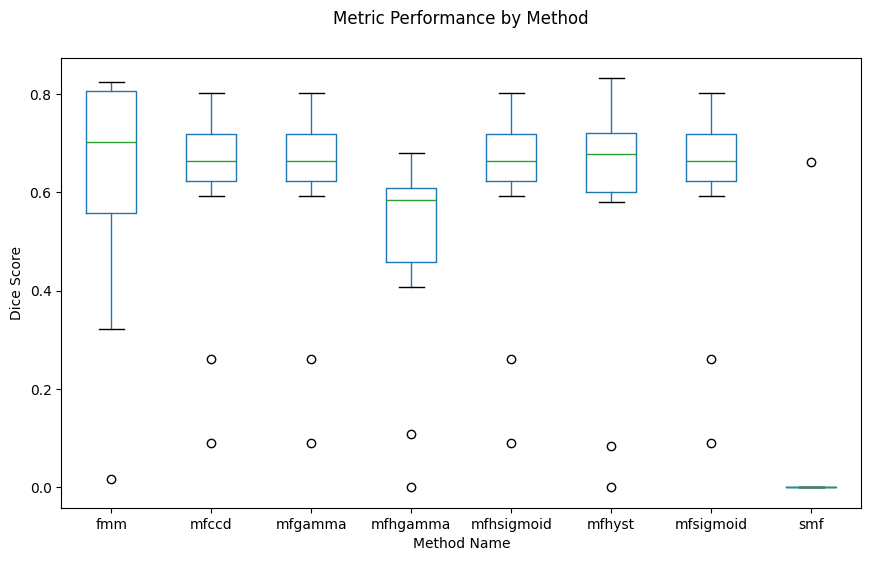

In [13]:
df_filtered = df[df["image_path"].isin(df_pruned.index)]
ax = df_filtered.boxplot(
    column="dice", by="method_name", figsize=(10, 6), grid=False
)
ax.set(title=None)
ax.set_xlabel('Method Name')
ax.set_ylabel('Dice Score')
plt.suptitle('Metric Performance by Method')

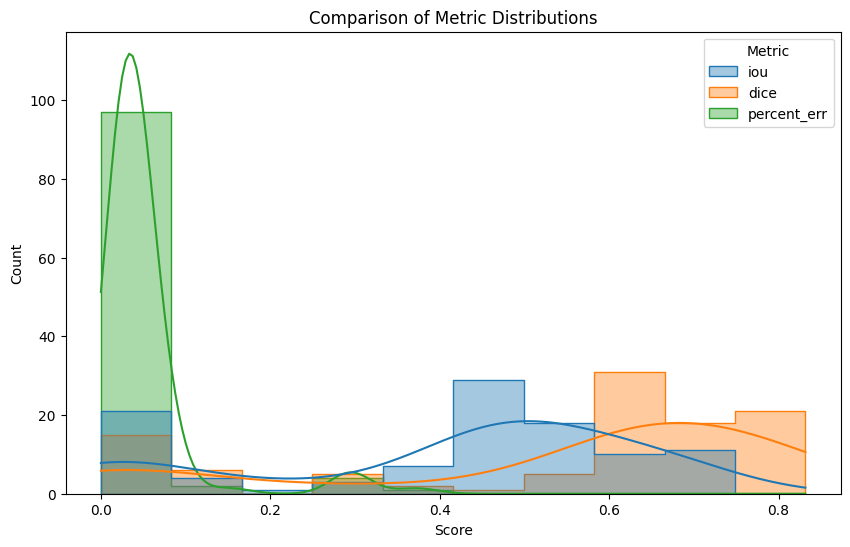

In [14]:
plt.figure(figsize=(10, 6))

df_filtered_melted = df_filtered.melt(
    value_vars=["iou", "dice", "percent_err"], var_name="Metric", value_name="Score"
)

sns.histplot(
    data=df_filtered_melted,
    x="Score",
    hue="Metric",
    kde=True,
    element="step",
    alpha=0.4,
)

plt.title("Comparison of Metric Distributions")
plt.show()